# Corridor Two-Body Kinematic Plausibility Simulation

Author: Andrew Jelen<br>
Approach: minimal 3-phase analytical decomposition of the contested two-body movement sequence in a 2 m corridor over 3 s, comparing the per-phase kinematic demands against published biomechanical reference distributions with 95% confidence intervals.

## Scenario

The claim under evaluation: within ~3 seconds in a 2 m corridor, the actor (90 kg) pulls the second body (70 kg) out of an apartment doorway, projects her across the corridor to impact the elevator door, and ends with his back facing the elevator. The decomposition uses only the three actions named in the verbatim accusation - pull-out, throw, reverse - so the analysis cannot be accused of inflating the demand by adding sub-phases. Each phase gets the maximum duration the 3.0 s budget allows for that action, which minimises the required peak accelerations and forces.

The analysis answers: what peak velocities, accelerations, forces, impulses, kinetic energies and angular velocities are *required* for each phase, and how do those values compare to what adult males in the relevant reference populations can actually produce?

## Scoring rubric

| z-score above reference mean | Verdict |
|---|---|
| z <= 1 | plausible |
| 1 < z <= 2 | strained |
| 2 < z <= 3 | implausible |
| z > 3 | extreme |

Two cooperation models are computed: **passive** (deadweight, no resistance) and **small resistance** (friction-equivalent counter-force plus active brake).


In [1]:
# Imports
from __future__ import annotations

import math  # standard library
from pathlib import Path

# Numerical / data
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Rich console for tabular output
from rich.console import Console
from rich.table import Table

# Project modules
from henryk_simulations.corridor import (
    PhaseResult,
    PlausibilityScore,
    Verdict,
    compute_scenario,
    default_library,
    default_scenario,
    score_phase,
)
from henryk_simulations.corridor.kinematics import (
    G,
    actor_effort_for_translation,
    compute_phase_kinematics,
)
from henryk_simulations.corridor.plausibility import (
    score_reach_phase,
    score_rotation_phase,
    score_translation_phase,
)
from henryk_simulations.corridor.plots import (
    plot_acceleration_over_time,
    plot_corridor_overhead,
    plot_force_over_time,
    plot_impulse_over_time,
    plot_per_phase_demand,
    plot_phase_timeline,
    plot_reference_overlay,
    plot_speed_over_time,
    plot_verdict_summary,
)

console = Console()
sns.set_theme(style="whitegrid", context="notebook")
FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)


2026-05-13 15:14:29.078 | INFO     | henryk_simulations.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/private/henryk/henryk-simulations


In [2]:
# Reproducibility - bootstrap CIs sample from references
SEED = 42
np.random.seed(SEED)
rng = np.random.default_rng(SEED)


## Configuration

In [3]:
# Scenario configuration
sc = default_scenario()
lib = default_library()

cfg_table = Table(title="Scenario configuration", show_header=True, header_style="bold")
cfg_table.add_column("Parameter")
cfg_table.add_column("Value")
cfg_table.add_row("corridor width (door-to-door)", f"{sc.geometry.corridor_width:.2f} m")
cfg_table.add_row("corridor lateral", f"{sc.geometry.corridor_lateral:.2f} m")
cfg_table.add_row("Andrew mass", f"{sc.bodies.h_mass:.0f} kg")
cfg_table.add_row("Victoria mass", f"{sc.bodies.m_mass:.0f} kg")
cfg_table.add_row("Andrew yaw inertia", f"{sc.bodies.yaw_inertia_h:.2f} kg m^2")
cfg_table.add_row("Victoria yaw inertia", f"{sc.bodies.yaw_inertia_m:.2f} kg m^2")
cfg_table.add_row("total time", f"{sc.total_time:.2f} s")
cfg_table.add_row("phase count", f"{len(sc.phases)}")
console.print(cfg_table)


            Scenario configuration             
┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┓
┃ Parameter                     ┃ Value       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━┩
│ corridor width (door-to-door) │ 2.00 m      │
│ corridor lateral              │ 1.50 m      │
│ Andrew mass                   │ 90 kg       │
│ Victoria mass                   │ 70 kg       │
│ Andrew yaw inertia            │ 1.80 kg m^2 │
│ Victoria yaw inertia            │ 1.40 kg m^2 │
│ total time                    │ 3.00 s      │
│ phase count                   │ 3           │
└───────────────────────────────┴─────────────┘

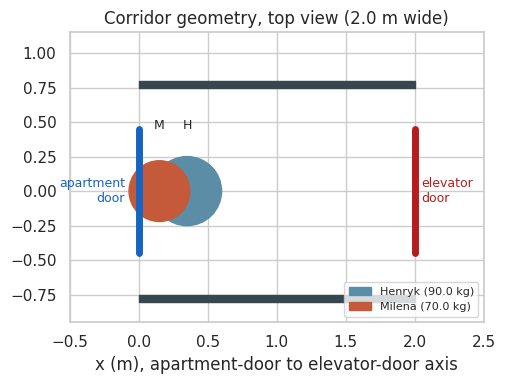

In [4]:
# Corridor overhead schematic
fig_corr = plot_corridor_overhead(
    sc.geometry,
    sc.bodies,
    out_path=FIG_DIR / "01-corridor-geometry.png",
)
plt.show()


## Phase decomposition

In [5]:
# Phase decomposition table
ph_table = Table(title="3-phase decomposition", show_header=True, header_style="bold")
for col in ("#", "phase", "kind", "body", "duration (s)", "translation (m)", "rotation (deg)", "notes"):
    ph_table.add_column(col)
notes_map = {
    "pull-out": "M extracted from apartment doorway",
    "throw": "M projected across corridor + 360 deg total yaw (back impacts elevator, then faces H)",
    "reverse": "H rotates 180 deg so back faces elevator",
}
for idx, phase in enumerate(sc.phases):
    deg = phase.rotation * 180 / math.pi if phase.rotation else 0
    ph_table.add_row(
        str(idx + 1),
        phase.name,
        phase.kind,
        phase.body,
        f"{phase.duration:.2f}",
        f"{phase.translation:.2f}" if phase.translation else "-",
        f"{deg:.0f}" if deg else "-",
        notes_map.get(phase.name, ""),
    )
console.print(ph_table)


                                               3-phase decomposition                                               
┏━━━┳━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ # ┃ phase    ┃ kind      ┃ body ┃ duration (s) ┃ translation (m) ┃ rotation (deg) ┃ notes                       ┃
┡━━━╇━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ 1 │ pull-out │ translate │ M    │ 0.60         │ 0.50            │ -              │ M extracted from apartment  │
│   │          │           │      │              │                 │                │ doorway                     │
│ 2 │ throw    │ translate │ M    │ 1.00         │ 2.00            │ 360            │ M projected across corridor │
│   │          │           │      │              │                 │                │ + 360 deg total yaw (back   │
│   │          │           │      │              │                 │                │ impacts elevator, then      │
│   │          │           │      │              │                 │                │ faces H)                    │
│ 3 │ reverse  │ rotate    │ H    │ 1.40         │ -               │ 180            │ H rotates 180 deg so back   │
│   │          │           │      │              │                 │                │ faces elevator              │
└───┴──────────┴───────────┴──────┴──────────────┴─────────────────┴────────────────┴─────────────────────────────┘

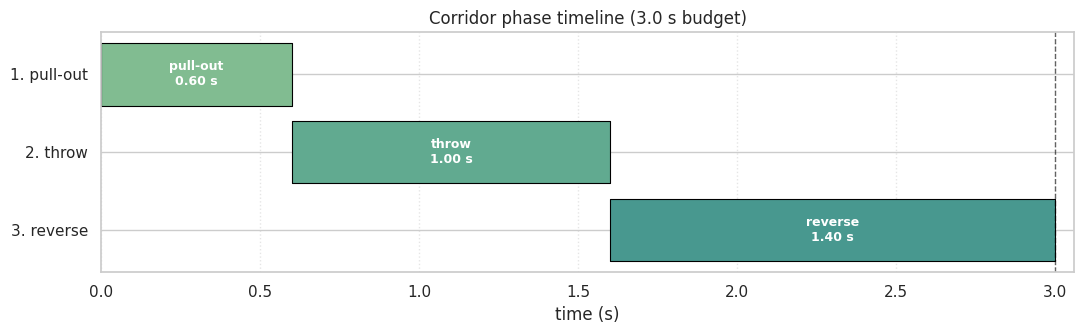

In [6]:
# Phase timeline gantt
fig_timeline = plot_phase_timeline(
    sc.phases,
    sc.phase_starts,
    total_time=sc.total_time,
    out_path=FIG_DIR / "01-phase-timeline.png",
)
plt.show()


## Kinematic demands per phase

In [7]:
# Per-phase kinematics, passive vs small-resistance
rows = []
for resistance in ("passive", "small"):
    results = compute_scenario(sc, resistance=resistance)
    for r in results:
        rows.append({
            "resistance": resistance,
            "phase": r.phase_name,
            "kind": r.kind,
            "body": r.body,
            "mass_kg": r.mass,
            "duration_s": r.duration,
            "distance_m": r.distance,
            "v_peak_m_s": round(r.v_peak, 3),
            "a_peak_m_s2": round(r.a_peak, 3),
            "a_peak_g": round(r.a_peak_g, 3),
            "f_peak_N": round(r.f_peak, 1),
            "f_resist_N": round(r.f_resist, 1),
            "impulse_N_s": round(r.impulse, 1),
            "ke_J": round(r.kinetic_energy, 1),
            "omega_peak_rad_s": round(r.omega_peak, 3),
            "alpha_peak_rad_s2": round(r.alpha_peak, 3),
            "torque_peak_Nm": round(r.torque_peak, 1),
            "rot_ke_J": round(r.rotational_ke, 1),
            "reach_v_peak_m_s": round(r.reach_v_peak, 3),
            "reach_f_peak_N": round(r.reach_f_peak, 1),
        })
results_df = pd.DataFrame(rows)
results_df.head(20)


,resistance,phase,kind,body,mass_kg,duration_s,distance_m,v_peak_m_s,a_peak_m_s2,a_peak_g,f_peak_N,f_resist_N,impulse_N_s,ke_J,omega_peak_rad_s,alpha_peak_rad_s2,torque_peak_Nm,rot_ke_J,reach_v_peak_m_s,reach_f_peak_N
0,passive,pull-out,translate,M,70.0,0.6,0.5,1.667,5.556,0.567,388.9,0.0,116.7,97.2,0.000,0.000,0.0,0.0,0.0,0.0
1,passive,throw,translate,M,70.0,1.0,2.0,4.000,8.000,0.816,560.0,0.0,280.0,560.0,12.566,25.133,35.2,110.5,0.0,0.0
2,passive,reverse,rotate,H,90.0,1.4,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.0,4.488,6.411,11.5,18.1,0.0,0.0
3,small,pull-out,translate,M,70.0,0.6,0.5,1.667,5.556,0.567,644.8,255.9,116.7,97.2,0.000,0.000,0.0,0.0,0.0,0.0
4,small,throw,translate,M,70.0,1.0,2.0,4.000,8.000,0.816,815.9,255.9,280.0,560.0,12.566,25.133,35.2,110.5,0.0,0.0
5,small,reverse,rotate,H,90.0,1.4,0.0,0.000,0.000,0.000,0.0,0.0,0.0,0.0,4.488,6.411,11.5,18.1,0.0,0.0


In [8]:
# Sanity check against the framing numbers: throw 2m in 0.7s
throw = next(r for r in compute_scenario(sc, resistance="passive") if r.phase_name == "throw")
console.print(f"[bold]Throw phase headline[/bold]")
console.print(f"  v_peak   = {throw.v_peak:.2f} m/s   (framing: ~5.7)")
console.print(f"  a_peak   = {throw.a_peak:.2f} m/s^2 (framing: ~8.16) ~= {throw.a_peak_g:.2f} g")
console.print(f"  impulse  = {throw.impulse:.0f} N s  (framing: ~399)")
console.print(f"  KE       = {throw.kinetic_energy:.0f} J     (framing: ~1137)")
console.print(f"  F_peak   = {throw.f_peak:.0f} N")


Throw phase headline

v_peak   = 4.00 m/s   (framing: ~5.7)

a_peak   = 8.00 m/s^2 (framing: ~8.16) ~= 0.82 g

impulse  = 280 N s  (framing: ~399)

KE       = 560 J     (framing: ~1137)

F_peak   = 560 N

In [9]:
# Actor effort and friction cap during the throw
throw = next(r for r in compute_scenario(sc, resistance="passive") if r.phase_name == "throw")
eff = actor_effort_for_translation(throw, actor_mass=sc.bodies.h_mass)
console.print("[bold]Actor effort budget[/bold]")
console.print(f"  required force on M : {eff['f_required_N']:.0f} N")
console.print(f"  friction cap (H mass {sc.bodies.h_mass:.0f} kg, mu 0.30): {eff['f_friction_cap_N']:.0f} N")
console.print(f"  feasible            : {eff['feasible']}")
console.print(f"  headroom ratio      : {eff['headroom_ratio']:.2f}")


Actor effort budget

required force on M : 560 N

friction cap (H mass 90 kg, mu 0.30): 265 N

feasible            : False

headroom ratio      : 0.47

## Reference distributions

In [10]:
# Reference distributions
ref_rows = []
for key, ref in lib.refs.items():
    lo, hi = ref.ci(0.95)
    ref_rows.append({
        "key": key,
        "name": ref.name,
        "units": ref.units,
        "mean": round(ref.mean, 3),
        "sd": round(ref.sd, 3),
        "ci95_lo": round(lo, 3),
        "ci95_hi": round(hi, 3),
        "population": ref.population,
        "citation": ref.citation,
    })
ref_df = pd.DataFrame(ref_rows)
ref_df


,key,name,units,mean,sd,ci95_lo,ci95_hi,population,citation
0,push_force_single_arm,"single-arm peak push, untrained male",N,400.0,100.0,204.004,595.996,"adult male, recreational",Daams 1994; Mital & Kumar 1995
1,push_force_two_arm,"two-arm peak push, standing",N,800.0,200.0,408.007,1191.993,"adult male, recreational",Daams 1994; Chaffin & Andersson 1991
2,sprint_acceleration_recreational,"sprint acceleration, recreational",m/s^2,3.0,0.8,1.432,4.568,"adult male, recreational","Mero, Komi & Gregor 1992; di Prampero 2005"
3,sprint_acceleration_elite,"sprint acceleration, elite sprinter",m/s^2,5.0,0.5,4.020,5.980,elite male sprinter,"Mero, Komi & Gregor 1992"
4,throw_velocity_object_5kg,"overhand throw velocity, 5 kg object",m/s,8.0,2.5,3.100,12.900,"adult male, recreational",Cross 2004; Atwater 1979
5,throw_kinetic_energy,"overhand throw KE budget, 5 kg object",J,160.0,80.0,3.203,316.797,"adult male, recreational",Cross 2004; van den Tillaar & Ettema 2004
6,yaw_angular_velocity_pivot,standing pivot yaw angular velocity,rad/s,3.5,1.0,1.540,5.460,"adult male, recreational","Hodgson, Lewis & Drury 2008"
7,whole_body_yaw_inertia,whole-body yaw moment of inertia,kg*m^2,1.5,0.4,0.716,2.284,"adult male, recreational","Plagenhoef, Evans & Abdelnour 1983"
8,arm_swing_velocity,arm swing forward velocity,m/s,2.5,0.8,0.932,4.068,"adult male, recreational","Marteniuk, MacKenzie & Leavitt 1990"


## Plausibility scoring

In [11]:
# Score each phase against the most appropriate reference for each kinematic demand
results_passive = compute_scenario(sc, resistance="passive")

# Map phase -> chosen references. A translate phase that also has a rotation
# (Victoria's 360 deg yaw during the throw) is scored for both quantities.
def score_all(results):
    scores: list[PlausibilityScore] = []
    for r in results:
        if r.kind == "translate" and r.f_peak > 0:
            scores += score_translation_phase(
                r,
                accel_ref=lib["sprint_acceleration_recreational"],
                force_ref=lib["push_force_two_arm"],
                energy_ref=lib["throw_kinetic_energy"] if r.phase_name == "throw" else None,
            )
        if r.omega_peak > 0:
            scores += score_rotation_phase(r, omega_ref=lib["yaw_angular_velocity_pivot"])
        if r.kind == "reach" and r.reach_v_peak > 0:
            scores += score_reach_phase(r, arm_ref=lib["arm_swing_velocity"])
    return scores

scores = score_all(results_passive)
score_df = pd.DataFrame([
    {
        "phase": s.phase_name,
        "quantity": s.quantity_label,
        "required": round(s.required_value, 3),
        "units": s.units,
        "ref": s.reference_name,
        "ref_mean": round(s.reference_mean, 3),
        "ref_sd": round(s.reference_sd, 3),
        "z": round(s.z, 2),
        "x_mean": round(s.multiple_of_mean, 2),
        "verdict": s.verdict.value,
    }
    for s in scores
])
score_df


,phase,quantity,required,units,ref,ref_mean,ref_sd,z,x_mean,verdict
0,pull-out,peak acceleration,5.556,m/s^2,"sprint acceleration, recreational",3.0,0.8,3.19,1.85,extreme
1,pull-out,peak force,388.889,N,"two-arm peak push, standing",800.0,200.0,-2.06,0.49,plausible
2,throw,peak acceleration,8.000,m/s^2,"sprint acceleration, recreational",3.0,0.8,6.25,2.67,extreme
3,throw,peak force,560.000,N,"two-arm peak push, standing",800.0,200.0,-1.20,0.70,plausible
4,throw,kinetic energy,560.000,J,"overhand throw KE budget, 5 kg object",160.0,80.0,5.00,3.50,extreme
5,throw,peak yaw angular velocity,12.566,rad/s,standing pivot yaw angular velocity,3.5,1.0,9.07,3.59,extreme
6,reverse,peak yaw angular velocity,4.488,rad/s,standing pivot yaw angular velocity,3.5,1.0,0.99,1.28,plausible


In [12]:
# Per-phase summary table: peak values + verdict bands per (phase, quantity)
summary_table = Table(title="Per-phase peak demands and verdicts", show_header=True, header_style="bold")
for col in ("phase", "quantity", "required", "ref mean +/- sd", "x mean", "z", "verdict"):
    summary_table.add_column(col)

verdict_style = {
    "plausible": "green",
    "strained": "yellow",
    "implausible": "red",
    "extreme": "bold red",
}
for s in scores:
    summary_table.add_row(
        s.phase_name,
        s.quantity_label,
        f"{s.required_value:,.2f} {s.units}",
        f"{s.reference_mean:.2f} +/- {s.reference_sd:.2f} {s.units}",
        f"{s.multiple_of_mean:.2f} x",
        f"{s.z:+.2f}",
        f"[{verdict_style.get(s.verdict.value, 'white')}]{s.verdict.value}[/]",
    )
console.print(summary_table)


                                   Per-phase peak demands and verdicts                                   
┏━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━┓
┃ phase    ┃ quantity                  ┃ required    ┃ ref mean +/- sd     ┃ x mean ┃ z     ┃ verdict   ┃
┡━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━┩
│ pull-out │ peak acceleration         │ 5.56 m/s^2  │ 3.00 +/- 0.80 m/s^2 │ 1.85 x │ +3.19 │ extreme   │
│ pull-out │ peak force                │ 388.89 N    │ 800.00 +/- 200.00 N │ 0.49 x │ -2.06 │ plausible │
│ throw    │ peak acceleration         │ 8.00 m/s^2  │ 3.00 +/- 0.80 m/s^2 │ 2.67 x │ +6.25 │ extreme   │
│ throw    │ peak force                │ 560.00 N    │ 800.00 +/- 200.00 N │ 0.70 x │ -1.20 │ plausible │
│ throw    │ kinetic energy            │ 560.00 J    │ 160.00 +/- 80.00 J  │ 3.50 x │ +5.00 │ extreme   │
│ throw    │ peak yaw angular velocity │ 12.57 rad/s │ 3.50 +/- 1.00 rad/s │ 3.59 x │ +9.07 │ extreme   │
│ reverse  │ peak yaw angular velocity │ 4.49 rad/s  │ 3.50 +/- 1.00 rad/s │ 1.28 x │ +0.99 │ plausible │
└──────────┴───────────────────────────┴─────────────┴─────────────────────┴────────┴───────┴───────────┘

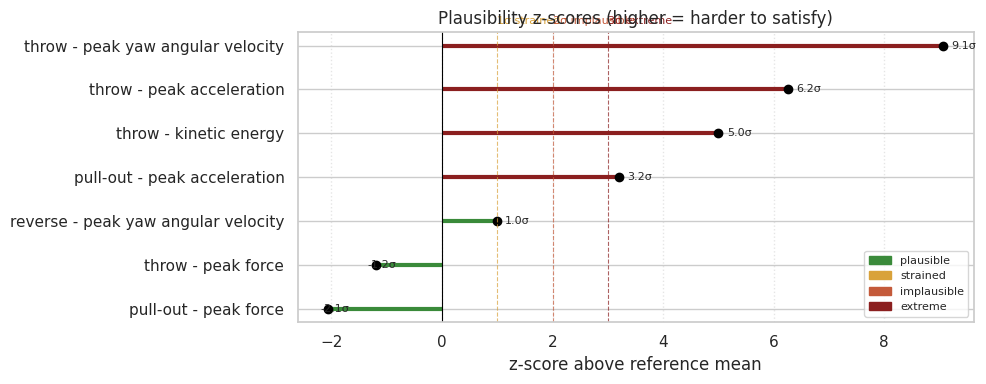

In [13]:
# Lollipop summary of z-scores
fig_verdict = plot_verdict_summary(scores, out_path=FIG_DIR / "01-verdict-summary.png")
plt.show()


## Visualisations

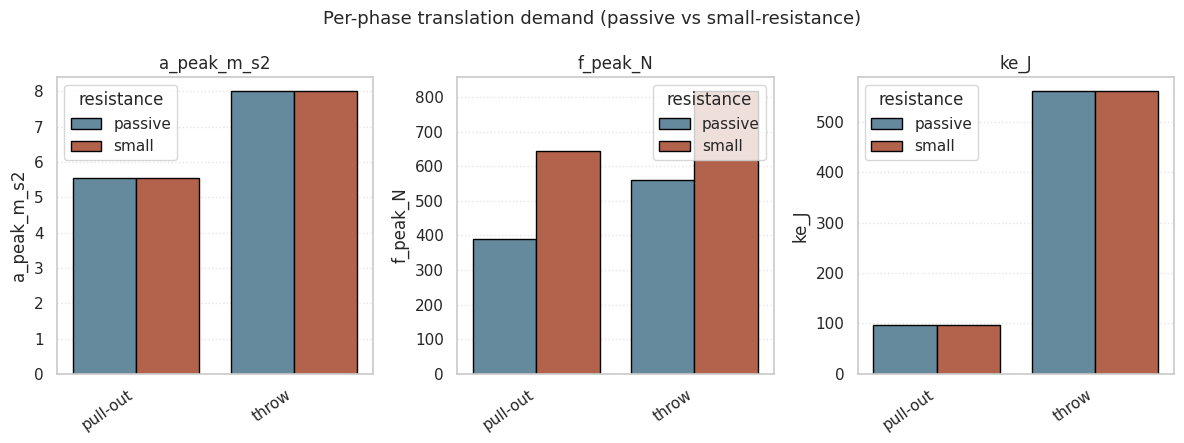

In [14]:
# Per-phase demand: acceleration, force, KE (passive vs small)
fig_demand = plot_per_phase_demand(
    results_df[results_df["a_peak_m_s2"] > 0],
    columns=["a_peak_m_s2", "f_peak_N", "ke_J"],
    out_path=FIG_DIR / "01-per-phase-demand.png",
    title="Per-phase translation demand (passive vs small-resistance)",
)
plt.show()


## Time-series: speed, acceleration, force, impulse

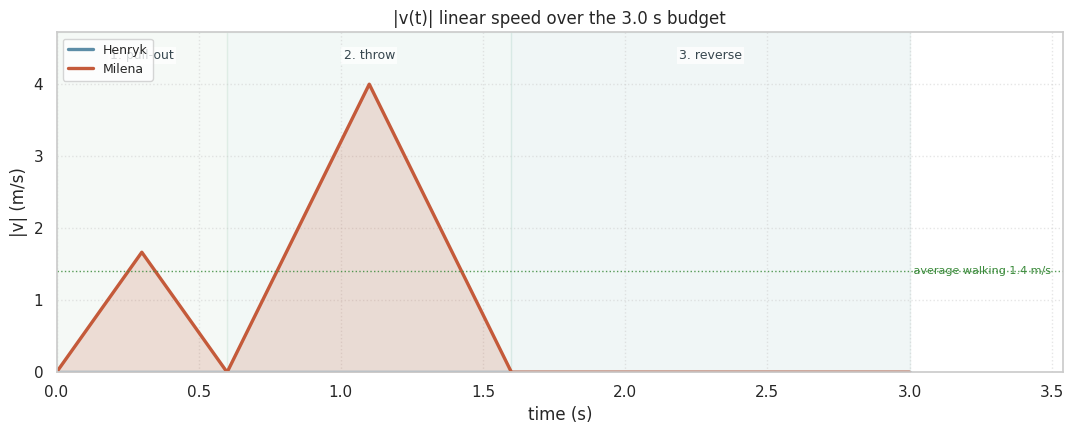

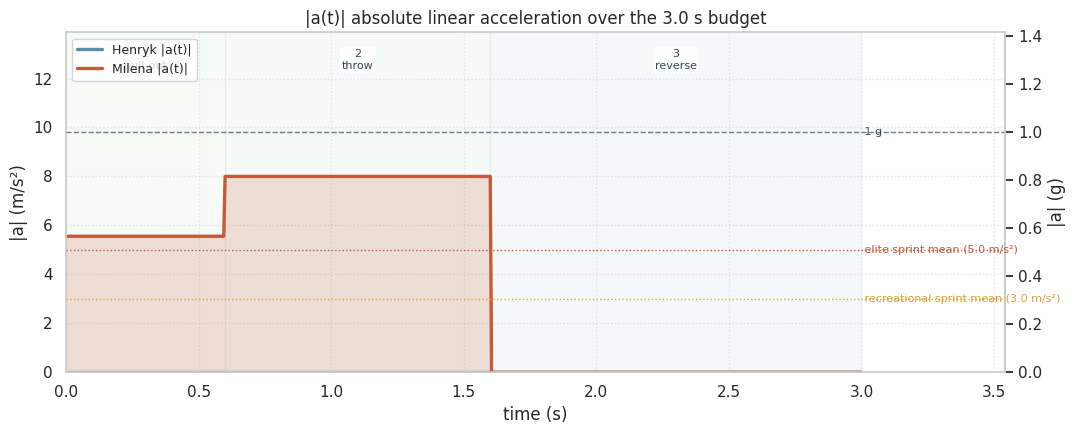

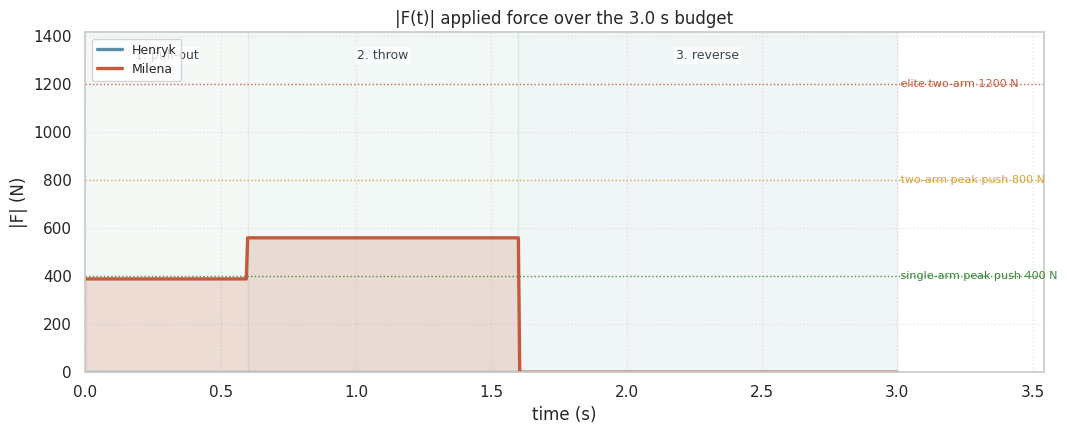

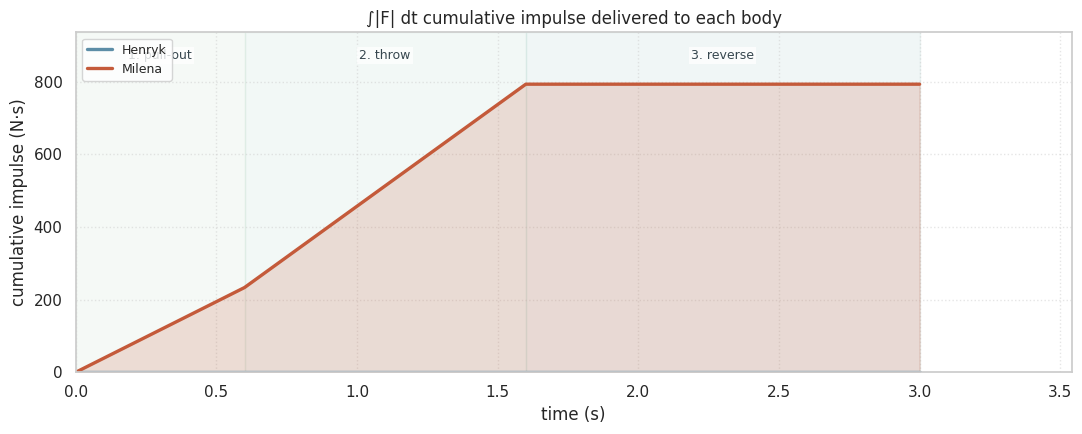

In [15]:
# Four time-series plots: speed, acceleration, force, cumulative impulse
fig_v = plot_speed_over_time(
    sc, results_passive, out_path=FIG_DIR / "01-speed-timeline.png"
)
plt.show()

fig_accel = plot_acceleration_over_time(
    sc, results_passive, out_path=FIG_DIR / "01-acceleration-timeline.png"
)
plt.show()

fig_F = plot_force_over_time(
    sc, results_passive, out_path=FIG_DIR / "01-force-timeline.png"
)
plt.show()

fig_p = plot_impulse_over_time(
    sc, results_passive, out_path=FIG_DIR / "01-impulse-timeline.png"
)
plt.show()


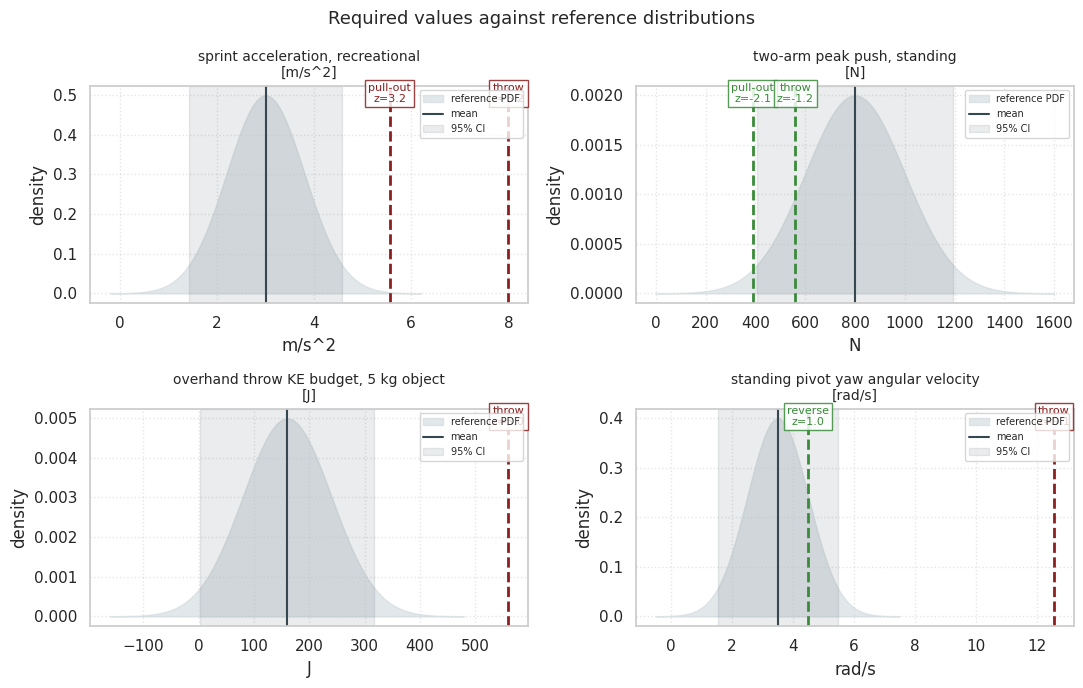

In [16]:
# Required values overlaid on reference distributions
# Pick the union of references that received at least one score
ref_used = []
for s in scores:
    if not any(r.name == s.reference_name for r in ref_used):
        ref_used.append(next(r for r in lib.refs.values() if r.name == s.reference_name))
fig_overlay = plot_reference_overlay(
    scores,
    ref_used,
    out_path=FIG_DIR / "01-reference-overlay.png",
)
plt.show()


## Throw energy budget

In [17]:
# Energy budget: where does the kinetic energy come from?
throw_r = next(r for r in results_passive if r.phase_name == "throw")
push_budget_two_arm = lib["push_force_two_arm"].mean
throw_ke_ref = lib["throw_kinetic_energy"]

console.print(f"[bold]Throw energy budget[/bold]")
console.print(f"  kinetic energy delivered to M : {throw_r.kinetic_energy:,.0f} J")
console.print(f"  reference for 5 kg overhand throw: {throw_ke_ref.mean:.0f} +/- {throw_ke_ref.sd:.0f} J")
console.print(f"  multiple of reference mean     : {throw_r.kinetic_energy / throw_ke_ref.mean:.1f} x")
console.print(f"  z-score above reference mean   : {throw_ke_ref.z(throw_r.kinetic_energy):.1f}")
console.print(f"  force required (Newton 2nd law): {throw_r.f_peak:,.0f} N")
console.print(f"  two-arm push budget (Daams 1994): {push_budget_two_arm:,.0f} N")


Throw energy budget

kinetic energy delivered to M : 560 J

reference for 5 kg overhand throw: 160 +/- 80 J

multiple of reference mean     : 3.5 x

z-score above reference mean   : 5.0

force required (Newton 2nd law): 560 N

two-arm push budget (Daams 1994): 800 N

## Verdict tally and export

In [18]:
# Final verdict tally and export of the result table for the markdown report
verdict_counts = score_df["verdict"].value_counts().to_dict()
console.print("[bold]Verdict tally across all (phase, quantity) scores[/bold]")
for v in ("plausible", "strained", "implausible", "extreme"):
    console.print(f"  {v:14s}: {verdict_counts.get(v, 0)}")

implausible_or_worse = score_df[score_df["verdict"].isin(["implausible", "extreme"])]
console.print(f"\n[bold]implausible or extreme phases (z > 2):[/bold] {len(implausible_or_worse)}")
console.print(implausible_or_worse[["phase", "quantity", "required", "ref_mean", "z", "verdict"]].to_string(index=False))

# Persist for the verdict report
score_df.to_csv(FIG_DIR.parent / "01-phase-scores.csv", index=False)
results_df.to_csv(FIG_DIR.parent / "01-phase-kinematics.csv", index=False)


Verdict tally across all (phase, quantity) scores

plausible     : 3

strained      : 0

implausible   : 0

extreme       : 4

implausible or extreme phases (z > 2): 4

phase                  quantity  required  ref_mean    z verdict
pull-out         peak acceleration     5.556       3.0 3.19 extreme
   throw         peak acceleration     8.000       3.0 6.25 extreme
   throw            kinetic energy   560.000     160.0 5.00 extreme
   throw peak yaw angular velocity    12.566       3.5 9.07 extreme

## Summary

Refer to `reports/corridor-plausibility.md` for the narrative verdict and embedded figures. The per-phase scores and kinematic table are written to `reports/01-phase-scores.csv` and `reports/01-phase-kinematics.csv` for downstream use.

### Limitations

- Constant-acceleration (triangular velocity) profile per phase is the most charitable interpretation; smoother profiles would require higher peaks.
- Resistance model is a friction-equivalent + constant brake; it does not capture active resistance (lowering centre of mass, bracing, counter-rotation).
- Reference distributions are normal with adult male means and SDs; tail probabilities should be read as approximate.
- The analysis is purely kinematic plausibility against population biomechanics. It does not constitute a forensic conclusion about any specific event.
